In [1]:
from py_files.setup import *
setup_notebook()

# Tax incidence: sweeping $\varepsilon^S$ and $\phi$

Maps the long-run factor price responses to a permanent capital income tax cut $d\log(1-\tau) > 0$ as functions of $\varepsilon^S$ and $\phi$. From Proposition 2, the responses around the undistorted steady state are

$$
    \frac{d\log r_K}{d\log(1-\tau)} = \frac{1}{\alpha_L}\cdot\frac{1}{\varepsilon^D + \varepsilon^S}, \qquad
    \frac{d\log w_C}{d\log(1-\tau)} = \frac{1}{\alpha_L}\cdot\frac{\alpha_K\varepsilon^S}{\varepsilon^D + \varepsilon^S}, \qquad
    \frac{d\log w_I}{d\log(1-\tau)} = \frac{1}{\alpha_L}\cdot\frac{1 + \beta_K\varepsilon^S}{\varepsilon^D + \varepsilon^S}.
$$

The left panel traces these as $\varepsilon^S$ varies directly and as $\phi$ shifts $\varepsilon^S$ endogenously. The limits deliver the key benchmarks: at $\varepsilon^S \to \infty$ the price effect vanishes and the NGM result is recovered; at $\varepsilon^S = 0$ the quantity effect vanishes and

$$
    \left.\frac{d\log r_K}{d\log(1-\tau)}\right|_{\varepsilon^S=0}
    = \left.\frac{d\log w_I}{d\log(1-\tau)}\right|_{\varepsilon^S=0}
    = \frac{1}{\alpha_L \cdot \varepsilon^D},
$$

so investment workers become, in effect, human capitalists. The right panel traces the full welfare incidence from simulation as $\phi$ varies continuously.

*`1. calibration`*

*calibrate to zero SS wage premia and target $\varepsilon_{nI} = (1-s_L)\phi$*

In [2]:
m = CapIncModel_single()
out = m.calibrate(target_elas=m.phi, verbose=False)

*`2. shock path`*

*permanent tax cut with geometric convergence — parameters $(\tau_0, \tau_T, \rho)$ set here*

In [3]:
T=25; tau0=0.0; rho=0.85; tail=50; tau_ss=0.0; tauT=-0.1

# permanent shock
net_long, tau_long, dlog_net_long, tauT = shocks.perm_tc(
    T=T, tau0=tau0, tauT=tauT, rho=rho, tail=tail,
)
# temp shock (uncomment to use instead)
# tauT = 0.0
# net_long, tau_long, dlog_net_long, tauT = shocks.temp_tc(T=T, tail=tail)

sim_raw = m.solve_transition(tau_path=tau_long, tau_terminal=tauT)
ss, sim = build_output_single.welfare_effects(
    m, sim_raw, tau_long, dlog_net_long, T=T, tail=tail, tau_ss=tau_ss
)
welf = elas.welfare_incidence(sim)

*`3. elasticities at baseline calibration`*

In [4]:
out_base = elas.dem_sup_elas(m, tau=0.0)
print(f"epsD={out_base['epsD']:.4f}  epsS_LR={out_base['epsS_LR']:.4f}  epsS_SR={out_base['epsS_SR']:.4f}")

# implied wage- and rent elasticities
# res = elas.wr_tax_elas(m, elas_out=out_base)
print_elas(out_base)

# NGM (alpha_L=beta_L=2/3) — uncomment to compare
# res_ncm = elas.wr_tax_elas(m, elas_out=out_base, epsS_LR=10000000000)
# print({k: round(v, 3) for k, v in res_ncm.items()})

epsD=1.4400  epsS_LR=1.5627  epsS_SR=0.1264
────────────────────────────────
  epsD           1.4400
  epsS_LR        1.5627
  epsS_SR        0.1264
────────────────────────────────


*`4. sweep`*

*marginal elasticities over $\varepsilon^S$-grid and $\phi$-grid; welfare incidence over $\phi$-grid from full simulation*

In [5]:
# sweep_res = run_sweeps(m, out_base, tau_long, dlog_net_long, tauT,
                    #    T, tail, tau_ss)

sweep_res = load_or_compute_sweeps(m, out_base, tau_long, dlog_net_long, tauT,
                                         T, tail, tau_ss)


Running epsS sweep …
Running phi marginal sweep …
Running phi welfare sweep …
Done.
Sweep results cached to sweep_cache_4b926dd6311b0f114c0e8bfa1403458b171cdafe.pkl


*`5. figure`*

*shaded band marks the calibration range; solid lines vary $\varepsilon^S$ directly, dashed lines vary $\phi$*

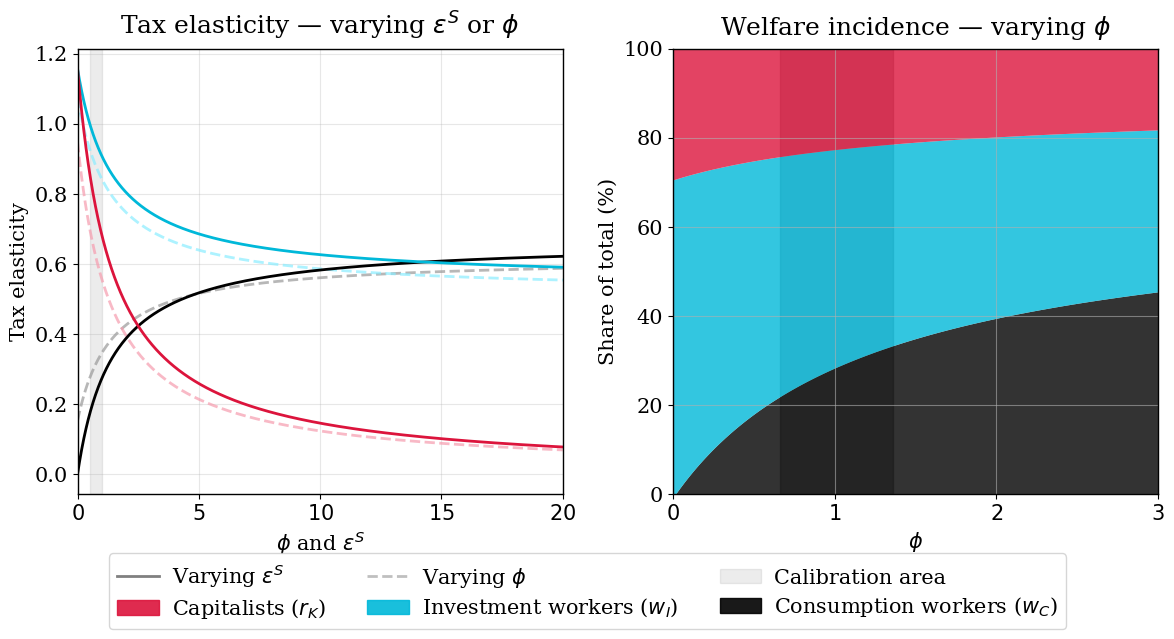

In [6]:
plot_sweep(sweep_res, savepath='0_output/main_arg.png')